In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import zipfile

zip_path = "/content/drive/MyDrive/archive (3).zip"

with zipfile.ZipFile(zip_path) as z:
    with z.open("all-data.csv") as f:
        df = pd.read_csv(
            f,
            encoding="latin-1",
            names=["Sentiment", "News Headline"]
        )

df.head()

,Sentiment,News Headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [ ]:
df.shape

(4846, 2)

In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
neutral,2879
positive,1363
negative,604


In [ ]:
df["Sentiment"].value_counts(normalize=True) * 100

,proportion
Sentiment,
neutral,59.409823
positive,28.126290
negative,12.463888


As classical model does understand raw text we need to clean the data, by making them uniform

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["News Headline"].apply(clean_text)

df[["News Headline", "clean_text", "Sentiment"]].head()

,News Headline,clean_text,Sentiment
0,"According to Gran , the company has no plans t...",according to gran the company has no plans to ...,neutral
1,Technopolis plans to develop in stages an area...,technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,the international electronic industry company ...,negative
3,With the new production plant the company woul...,with the new production plant the company woul...,positive
4,According to the company 's updated strategy f...,according to the company s updated strategy fo...,positive


Split into train and test

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training data shape: (3876,)
Testing data shape: (970,)

Training class distribution:
Sentiment
neutral     59.416925
positive    28.121775
negative    12.461300
Name: proportion, dtype: float64

Testing class distribution:
Sentiment
neutral     59.381443
positive    28.144330
negative    12.474227
Name: proportion, dtype: float64


now we need to convert these words into vectors

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (3876, 5000)
TF-IDF testing shape: (970, 5000)


now train with logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_tfidf, y_train)

print("Model training completed.")
print("Classes learned:", log_reg.classes_)

Model training completed.
Classes learned: ['negative' 'neutral' 'positive']


check the trained data

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

classical_preds = log_reg.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, classical_preds)
macro_f1 = f1_score(y_test, classical_preds, average="macro")

print("TF-IDF + Logistic Regression Results")
print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

print("\nClassification Report:")
print(classification_report(y_test, classical_preds))

TF-IDF + Logistic Regression Results
Accuracy: 0.7298969072164948
Macro F1: 0.67961110128582

Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.67      0.62       121
     neutral       0.81      0.81      0.81       576
    positive       0.64      0.59      0.61       273

    accuracy                           0.73       970
   macro avg       0.67      0.69      0.68       970
weighted avg       0.73      0.73      0.73       970



The model performing well on neutral as it is the majority class, but the accuracy drops on positive and negative, now we need confusion matrix so see where it actually goes wrong

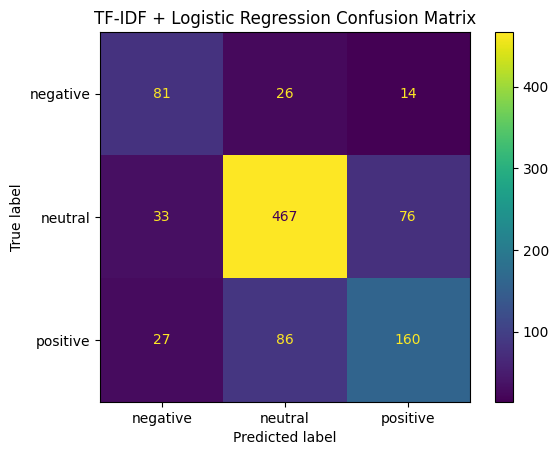

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    classical_preds,
    labels=["negative", "neutral", "positive"]
)

plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.show()

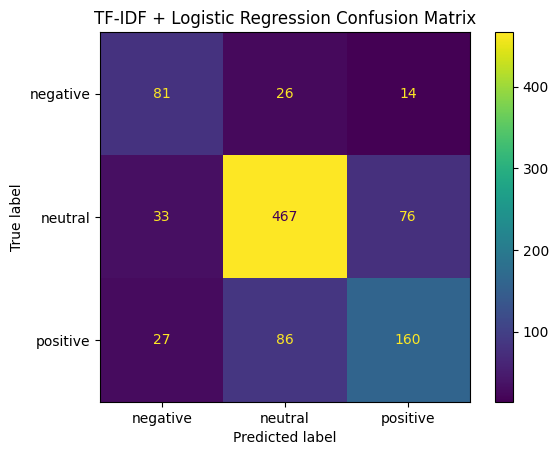

,Model,Accuracy,Macro F1
0,TF-IDF + Logistic Regression,0.729897,0.679611


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

os.makedirs("results", exist_ok=True)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    classical_preds,
    labels=["negative", "neutral", "positive"]
)

plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.savefig("results/classical_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

classical_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Macro F1": [macro_f1]
})

classical_results.to_csv("results/classical_metrics.csv", index=False)

classical_results

installing transformer from hugging face.

In [ ]:
!pip install -q transformers datasets accelerate

In [ ]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

bert_train_df = df.loc[X_train.index, ["News Headline", "Sentiment"]].copy()
bert_test_df = df.loc[X_test.index, ["News Headline", "Sentiment"]].copy()

bert_train_df["label"] = bert_train_df["Sentiment"].map(label2id)
bert_test_df["label"] = bert_test_df["Sentiment"].map(label2id)

bert_train_df = bert_train_df.rename(columns={"News Headline": "text"})
bert_test_df = bert_test_df.rename(columns={"News Headline": "text"})

bert_train_df = bert_train_df[["text", "label"]]
bert_test_df = bert_test_df[["text", "label"]]

print("BERT train shape:", bert_train_df.shape)
print("BERT test shape:", bert_test_df.shape)

bert_train_df.head()

BERT train shape: (3876, 2)
BERT test shape: (970, 2)


,text,label
132,The major breweries increased their domestic b...,2
1189,"CapMan , an asset manager , has EUR 3bn worth ...",1
798,`` The trend in the sports and leisure markets...,2
2000,`` In the newly formed company YIT Stavo the l...,2
3488,`` We have a group of 120 volunteers made up o...,1


Convert pandas to hugging face dataset

In [ ]:
from datasets import Dataset

bert_train_dataset = Dataset.from_pandas(bert_train_df)
bert_test_dataset = Dataset.from_pandas(bert_test_df)

print(bert_train_dataset)
print(bert_test_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 3876
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 970
})


Load distillbert tokenizer

In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer loaded successfully


we should tokenize all the train and test data completely.

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = bert_train_dataset.map(tokenize_function, batched=True)
tokenized_test = bert_test_dataset.map(tokenize_function, batched=True)

print(tokenized_train)
print(tokenized_test)

Map:   0%|          | 0/3876 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3876
})
Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 970
})


we dont need text anymore, bert only needs input id, attention mask, labels

In [ ]:
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

print(tokenized_train)
print(tokenized_test)

Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3876
})
Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 970
})


now we need pretrained DistilBERT model and prepares it for 3-class sentiment classification.

In [ ]:
from transformers import AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded successfully")
print("Number of labels:", model.config.num_labels)
print("ID to Label mapping:", model.config.id2label)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Number of labels: 3
ID to Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


we neeed to test the evalution metrics that we will later on ie after training.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
from transformers import TrainingArguments
import torch

training_args = TrainingArguments(
    output_dir="distilbert-financial-sentiment",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available()
)

print("Training arguments created successfully")

Training arguments created successfully


create the trainer from hugging face.

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

print("Trainer created successfully")

Trainer created successfully


now we train the data.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.422398,0.404174,0.832990,0.809249
2,0.288676,0.441617,0.813402,0.808379
3,0.151272,0.448462,0.837113,0.824324


TrainOutput(global_step=729, training_loss=0.35460462949567045, metrics={'train_runtime': 43.5795, 'train_samples_per_second': 266.823, 'train_steps_per_second': 16.728, 'total_flos': 385089595296768.0, 'train_loss': 0.35460462949567045, 'epoch': 3.0})

In [ ]:
bert_eval_results = trainer.evaluate()

bert_eval_results

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.151272,0.448462,3,0.837113,0.824324


{'eval_loss': 0.4484621584415436,
 'eval_accuracy': 0.8371134020618557,
 'eval_macro_f1': 0.824323591144525}

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

bert_output = trainer.predict(tokenized_test)

bert_logits = bert_output.predictions
bert_true_ids = bert_output.label_ids
bert_pred_ids = np.argmax(bert_logits, axis=1)

bert_accuracy = accuracy_score(bert_true_ids, bert_pred_ids)
bert_macro_f1 = f1_score(bert_true_ids, bert_pred_ids, average="macro")

print("DistilBERT Results")
print("Accuracy:", bert_accuracy)
print("Macro F1:", bert_macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        bert_true_ids,
        bert_pred_ids,
        target_names=["negative", "neutral", "positive"]
    )
)

DistilBERT Results
Accuracy: 0.8371134020618557
Macro F1: 0.824323591144525

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.92      0.83       121
     neutral       0.89      0.85      0.87       576
    positive       0.78      0.78      0.78       273

    accuracy                           0.84       970
   macro avg       0.81      0.85      0.82       970
weighted avg       0.84      0.84      0.84       970



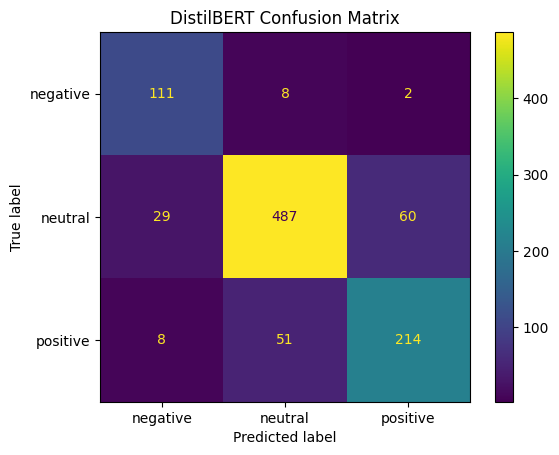

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

display_labels = ["negative", "neutral", "positive"]

ConfusionMatrixDisplay.from_predictions(
    bert_true_ids,
    bert_pred_ids,
    display_labels=display_labels
)

plt.title("DistilBERT Confusion Matrix")
plt.savefig("results/distilbert_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Compare the classical TF_IDF to distillBERT results.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        accuracy,
        bert_accuracy
    ],
    "Macro F1": [
        macro_f1,
        bert_macro_f1
    ]
})

comparison

,Model,Accuracy,Macro F1
0,TF-IDF + Logistic Regression,0.729897,0.679611
1,DistilBERT,0.837113,0.824324


In [ ]:
!pip install -U datasets transformers accelerate
!pip uninstall -y torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
trainer.train()

NameError: name 'trainer' is not defined